In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('/content/AAPL.csv', parse_dates=['Date'], index_col='Date')

# Display the first few rows
print(data.head())

# Summary statistics
print(data.describe())

# Data types and unique values
print(data.info())

                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929     1.696429 

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


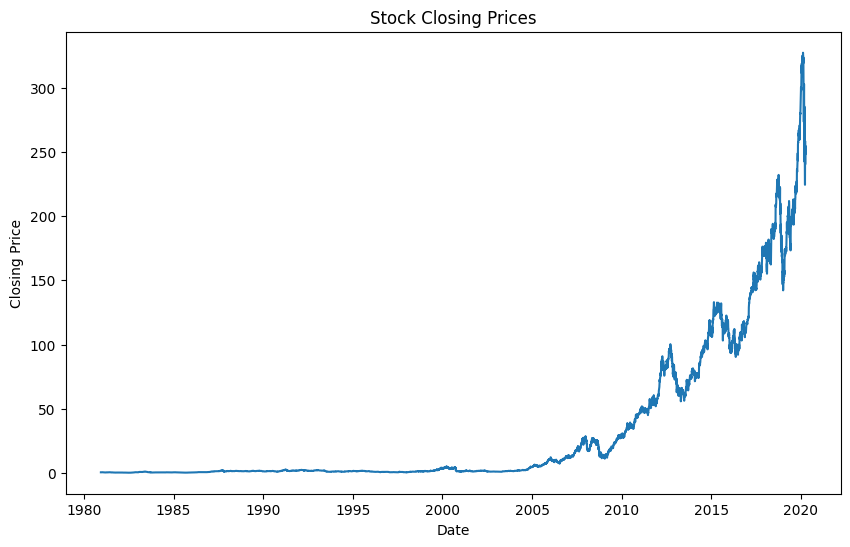

In [2]:
# Check for missing values
print(data.isnull().sum())

# Fill missing values if any
data.fillna(method='ffill', inplace=True)

# Visualize the closing price
plt.figure(figsize=(10,6))
plt.plot(data['Close'])
plt.title('Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

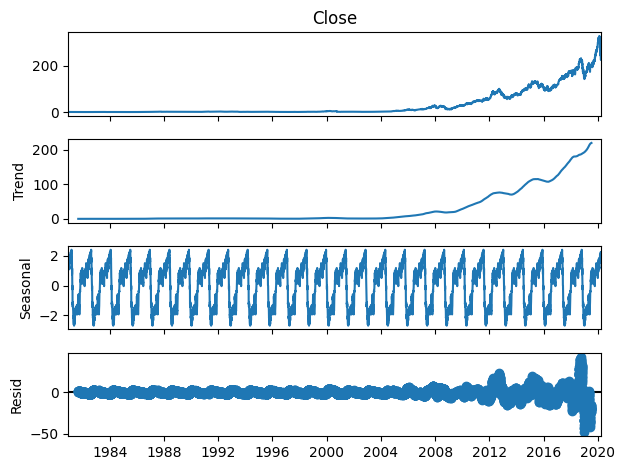

<Figure size 1200x600 with 0 Axes>

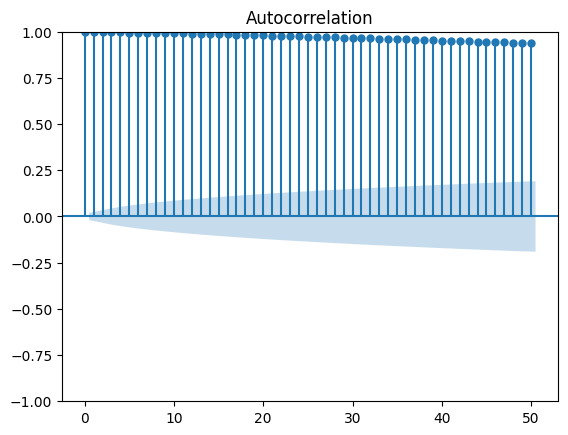

<Figure size 1200x600 with 0 Axes>

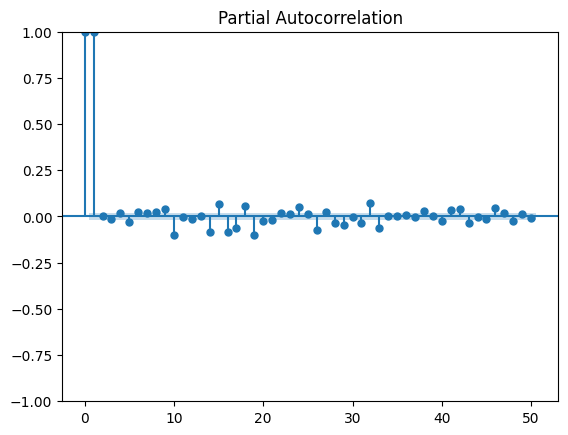

In [3]:
# Decompose the time series to observe trend, seasonality, and residuals
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['Close'], model='additive', period=365)
fig = decomposition.plot()
plt.show()

# Plotting the autocorrelation and partial autocorrelation functions
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,6))
plot_acf(data['Close'], lags=50)
plt.show()

plt.figure(figsize=(12,6))
plot_pacf(data['Close'], lags=50)
plt.show()

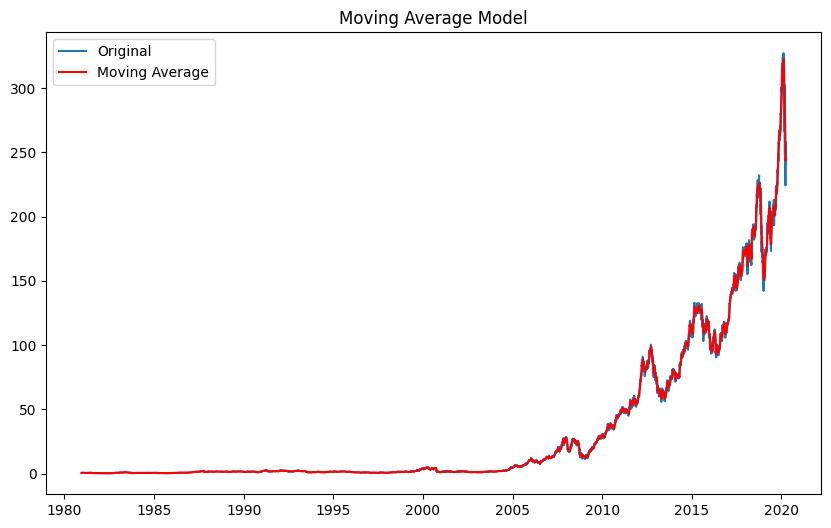

In [4]:
# Moving Average model
data['MA_Close'] = data['Close'].rolling(window=10).mean()

plt.figure(figsize=(10,6))
plt.plot(data['Close'], label='Original')
plt.plot(data['MA_Close'], label='Moving Average', color='red')
plt.title('Moving Average Model')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


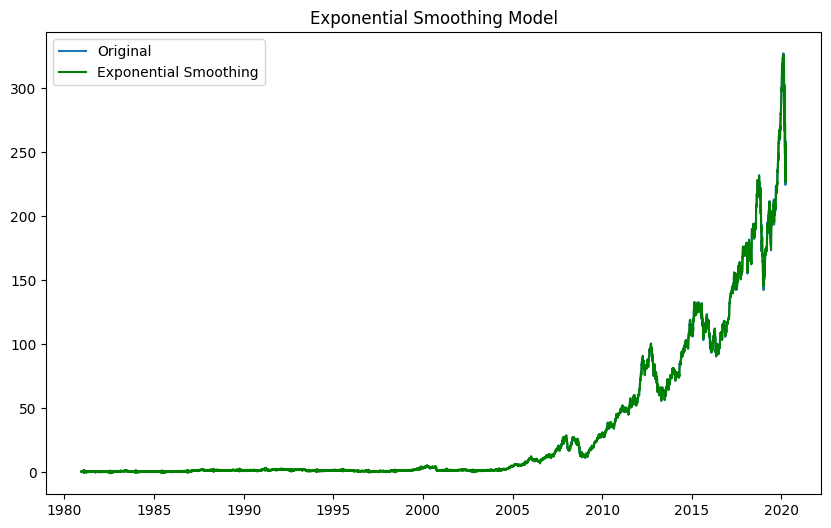

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Exponential Smoothing model
model_es = ExponentialSmoothing(data['Close'], trend='add', seasonal='add', seasonal_periods=365)
fit_es = model_es.fit()

data['ES_Close'] = fit_es.fittedvalues

plt.figure(figsize=(10,6))
plt.plot(data['Close'], label='Original')
plt.plot(data['ES_Close'], label='Exponential Smoothing', color='green')
plt.title('Exponential Smoothing Model')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


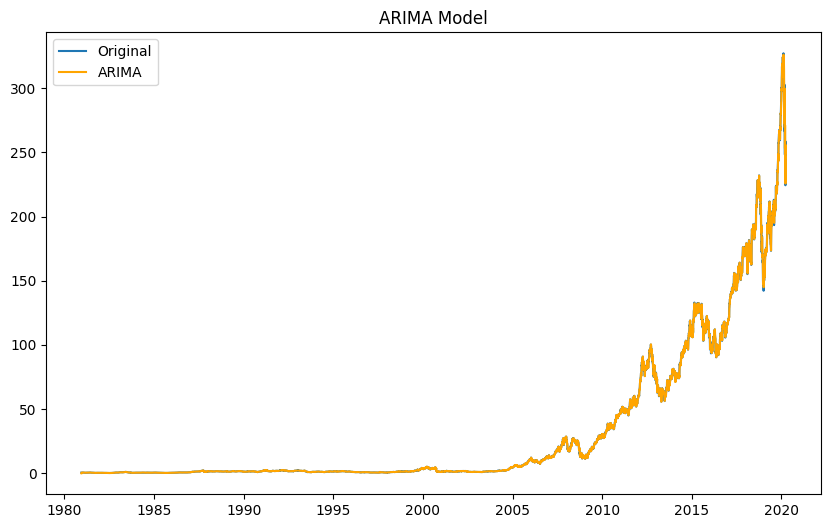

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model
model_arima = ARIMA(data['Close'], order=(5,1,0))
fit_arima = model_arima.fit()

data['ARIMA_Close'] = fit_arima.fittedvalues

plt.figure(figsize=(10,6))
plt.plot(data['Close'], label='Original')
plt.plot(data['ARIMA_Close'], label='ARIMA', color='orange')
plt.title('ARIMA Model')
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluation for Exponential Smoothing
es_mae = mean_absolute_error(data['Close'], data['ES_Close'])
es_mse = mean_squared_error(data['Close'], data['ES_Close'])
es_rmse = np.sqrt(es_mse)

print(f'Exponential Smoothing MAE: {es_mae}')
print(f'Exponential Smoothing MSE: {es_mse}')
print(f'Exponential Smoothing RMSE: {es_rmse}')

# Evaluation for ARIMA
arima_mae = mean_absolute_error(data['Close'], data['ARIMA_Close'])
arima_mse = mean_squared_error(data['Close'], data['ARIMA_Close'])
arima_rmse = np.sqrt(arima_mse)

print(f'ARIMA MAE: {arima_mae}')
print(f'ARIMA MSE: {arima_mse}')
print(f'ARIMA RMSE: {arima_rmse}')

Exponential Smoothing MAE: 0.5177447372225459
Exponential Smoothing MSE: 1.6784003634717861
Exponential Smoothing RMSE: 1.2955309195352251
ARIMA MAE: 0.4276899224275887
ARIMA MSE: 1.7267924672036101
ARIMA RMSE: 1.314074757083329


In [11]:
# Feature importance from ARIMA
print(f"ARIMA model summary: {fit_arima.summary()}")

# Recommendations
print("Recommendations:")
print("1. Moving Average provides a simple but effective method for smoothing out noise in the data.")
print("2. Exponential Smoothing is useful for capturing trends and seasonality.")
print("3. ARIMA offers a robust approach for capturing complex patterns in the data.")
print("4. Monitor stock prices regularly and update the models as new data becomes available.")
print("5. Use the models to make informed decisions about buying or selling stocks based on predicted trends.")

ARIMA model summary:                                SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 9909
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -16765.491
Date:                Wed, 17 Jul 2024   AIC                          33542.981
Time:                        08:08:46   BIC                          33586.188
Sample:                             0   HQIC                         33557.613
                               - 9909                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1762      0.002    -96.123      0.000      -0.180      -0.173
ar.L2          0.0049      0.002      3.157      0.002       0.002       0.008
ar.L3          0.0163      0.00